# Milestone 1: Review Analysis & Sentiment Classification


In [1]:

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

#nltk.download('vader_lexicon')



In [2]:

# Load datasets
apps = pd.read_csv('googleplaystore.csv')
reviews = pd.read_csv('googleplaystore_user_reviews.csv')


In [3]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [5]:
print("Shape Apps: ",apps.shape)
print("Reviews Apps: ",reviews.shape)

Shape Apps:  (10841, 13)
Reviews Apps:  (64295, 5)


In [6]:

# Keeping only apps in "Health & Fitness" or "Health_and_Fitness" category
apps = apps[apps['Category']=='HEALTH_AND_FITNESS']

## Converting the Reviews column into a interger from object as its a numerical field using astype() function.
apps['Reviews'] = apps['Reviews'].astype(int)

## Keeping only Apps with 100 or more reviews
apps = apps[apps['Reviews'] >= 100]

## Showing Tops 30 Apps by review
apps.sort_values('Reviews', ascending=False).head(30)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1360,Period Tracker - Period Calendar Ovulation Tra...,HEALTH_AND_FITNESS,4.8,4559407,Varies with device,"100,000,000+",Free,0,Everyone,Health & Fitness,"August 1, 2018",Varies with device,Varies with device
1362,Calorie Counter - MyFitnessPal,HEALTH_AND_FITNESS,4.6,1873523,Varies with device,"50,000,000+",Free,0,Everyone,Health & Fitness,"July 31, 2018",Varies with device,Varies with device
1421,Calorie Counter - MyFitnessPal,HEALTH_AND_FITNESS,4.6,1873523,Varies with device,"50,000,000+",Free,0,Everyone,Health & Fitness,"July 31, 2018",Varies with device,Varies with device
1386,Calorie Counter - MyFitnessPal,HEALTH_AND_FITNESS,4.6,1873520,Varies with device,"50,000,000+",Free,0,Everyone,Health & Fitness,"July 31, 2018",Varies with device,Varies with device
1404,Calorie Counter - MyFitnessPal,HEALTH_AND_FITNESS,4.6,1873520,Varies with device,"50,000,000+",Free,0,Everyone,Health & Fitness,"July 31, 2018",Varies with device,Varies with device
1286,Calorie Counter - MyFitnessPal,HEALTH_AND_FITNESS,4.6,1873516,Varies with device,"50,000,000+",Free,0,Everyone,Health & Fitness,"July 31, 2018",Varies with device,Varies with device
1391,Runtastic Running App & Mile Tracker,HEALTH_AND_FITNESS,4.5,827653,Varies with device,"10,000,000+",Free,0,Everyone,Health & Fitness,"July 25, 2018",Varies with device,Varies with device
1323,Runtastic Running App & Mile Tracker,HEALTH_AND_FITNESS,4.5,827651,Varies with device,"10,000,000+",Free,0,Everyone,Health & Fitness,"July 25, 2018",Varies with device,Varies with device
1277,Runtastic Running App & Mile Tracker,HEALTH_AND_FITNESS,4.5,827597,Varies with device,"10,000,000+",Free,0,Everyone,Health & Fitness,"July 25, 2018",Varies with device,Varies with device
1389,Nike+ Run Club,HEALTH_AND_FITNESS,4.4,708753,Varies with device,"10,000,000+",Free,0,Everyone,Health & Fitness,"July 12, 2018",2.17.0,4.4 and up


In [7]:
apps.shape

(254, 13)

In [8]:

# Merge reviews with metadata
df = apps.merge(reviews, on='App', how='inner')


In [9]:

# Data cleaning
df = df.dropna(subset=['Translated_Review'])
df = df[df['Translated_Review'].str.len() >= 10]
df['Translated_Review'] = df['Translated_Review'].astype(str)
df = df.drop_duplicates(subset=['App','Translated_Review'])

df.shape


(1541, 17)

In [10]:
df.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Home Workout - No Equipment,HEALTH_AND_FITNESS,4.8,428156,15M,"10,000,000+",Free,0,Everyone,Health & Fitness,"June 28, 2018",Varies with device,Varies with device,"I'm 39 year old woman I practice pole fitness,...",Positive,0.298958,0.636458
1,Home Workout - No Equipment,HEALTH_AND_FITNESS,4.8,428156,15M,"10,000,000+",Free,0,Everyone,Health & Fitness,"June 28, 2018",Varies with device,Varies with device,Many thanks LFG great app. I looking suitable ...,Positive,0.373810,0.480754
3,Home Workout - No Equipment,HEALTH_AND_FITNESS,4.8,428156,15M,"10,000,000+",Free,0,Everyone,Health & Fitness,"June 28, 2018",Varies with device,Varies with device,I love it. Even weightlifting brings whole new...,Positive,0.318636,0.433788


In [11]:
# Descriptive statistics - Rating Distribution

#Count of reviews by rating
print(df['Rating'].value_counts().sort_index())

# Percentage Distribution across ratings
percentages  = df['Rating'].value_counts(normalize=True).sort_index().mul(100).round(1).astype(str) + '%'
print(percentages)

# Average rating across all reviews
print('\nThe Average Rating across all the reviews is : ', df['Rating'].mean())


Rating
3.7      4
3.9     81
4.0    178
4.1     78
4.2     63
4.3    118
4.4    162
4.5    288
4.6    344
4.7    109
4.8     76
4.9     40
Name: count, dtype: int64
Rating
3.7     0.3%
3.9     5.3%
4.0    11.6%
4.1     5.1%
4.2     4.1%
4.3     7.7%
4.4    10.5%
4.5    18.7%
4.6    22.3%
4.7     7.1%
4.8     4.9%
4.9     2.6%
Name: proportion, dtype: object

The Average Rating across all the reviews is :  4.411940298507463


In [12]:
# Review length Analysis

df['Review_Length'] = df['Translated_Review'].apply(len)

# Averge Review Length
print('The average review length is: ',df.Review_Length.mean())

# Median Review Length
print('\nThe median review length is: ',df.Review_Length.median())

# Min and max Review Length
print('\nThe min review length is: ',df.Review_Length.min())
print('\nThe max review length is: ',df.Review_Length.max())

The average review length is:  121.09474367293964

The median review length is:  97.0

The min review length is:  10

The max review length is:  914


In [13]:
#Compare review length across ratings 
df.groupby('Rating')['Review_Length'].mean()

# It appears that both the lowest and highest ratings tend to have close to the average ratings , where as the the ratings 4.1, 4.2 and 4.3 Tend to have lower that the average

Rating
3.7    104.250000
3.9    154.061728
4.0    132.303371
4.1     65.692308
4.2     87.634921
4.3     66.855932
4.4    136.209877
4.5    113.107639
4.6    133.122093
4.7    117.614679
4.8    114.723684
4.9    241.325000
Name: Review_Length, dtype: float64

###### It appears that both the lowest and highest ratings tend to have close to the average ratings , where as the the ratings 4.1, 4.2 and 4.3 Tend to have lower that the average

In [14]:
# Descriptive statistics - Sentiment Distribution

sentiment_dist = df['Sentiment'].value_counts().sort_index()
print(sentiment_dist)
print('\nPercentage distribution of sentiment: ',df['Sentiment'].value_counts(normalize=True).sort_index().mul(100).round(1).astype(str) + '%')

Sentiment
Negative     175
Neutral      169
Positive    1197
Name: count, dtype: int64

Percentage distribution of sentiment:  Sentiment
Negative    11.4%
Neutral     11.0%
Positive    77.7%
Name: proportion, dtype: object


In [15]:

# VADER Sentiment
sia = SentimentIntensityAnalyzer()

df['vader_score'] = df['Translated_Review'].apply(lambda x: sia.polarity_scores(x)['compound'])

def classify(score):
    if score >= 0.05: return 'Positive'
    if score <= -0.05: return 'Negative'
    return 'Neutral'

df['Sentiment_VADER'] = df['vader_score'].apply(classify)


In [16]:

# Validation accuracy
accuracy = (df['Sentiment'] == df['Sentiment_VADER']).mean()
print('Accuracy of Sentiment: ',accuracy)


Accuracy of Sentiment:  0.8170019467878001


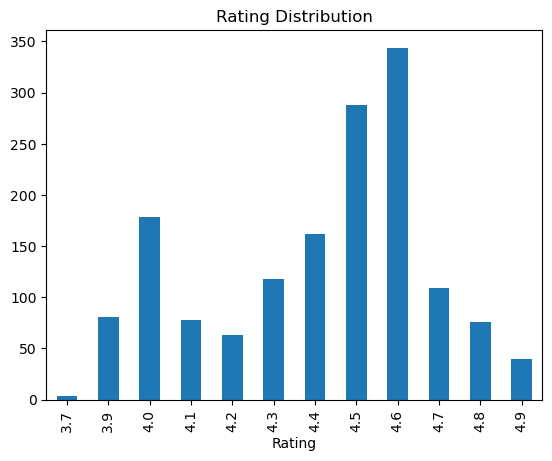

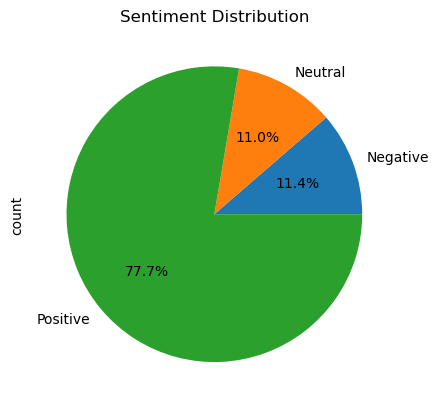

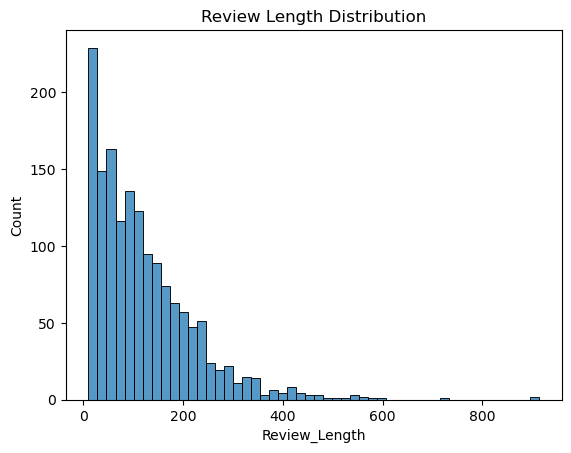

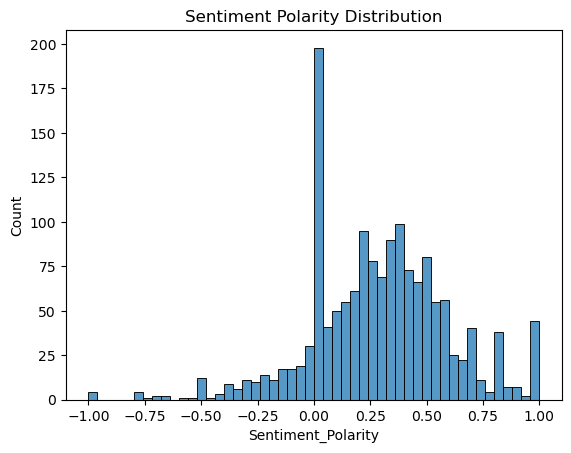

In [17]:

# Visualizations
plt.figure()
df['Rating'].value_counts().sort_index().plot(kind='bar', title='Rating Distribution')
plt.show()

plt.figure()
sentiment_dist.plot(kind='pie', autopct='%1.1f%%', title='Sentiment Distribution')
plt.show()

plt.figure()
sns.histplot(df['Review_Length'], bins=50)
plt.title('Review Length Distribution')
plt.show()

plt.figure()
sns.histplot(df['Sentiment_Polarity'], bins=50)
plt.title('Sentiment Polarity Distribution')
plt.show()


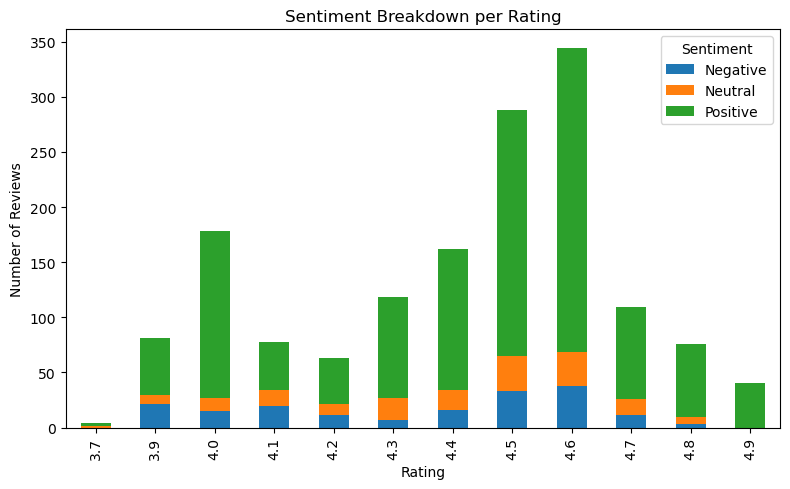

In [18]:
# Stacked bar chart showing sentiment breakdown per rating

#sns.countplot(data = df, x = 'Rating', hue='Sentiment')
stacked_df = (
    df
    .groupby(['Rating', 'Sentiment'])
    .size()
    .unstack(fill_value=0)
)
stacked_df.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.title('Sentiment Breakdown per Rating')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

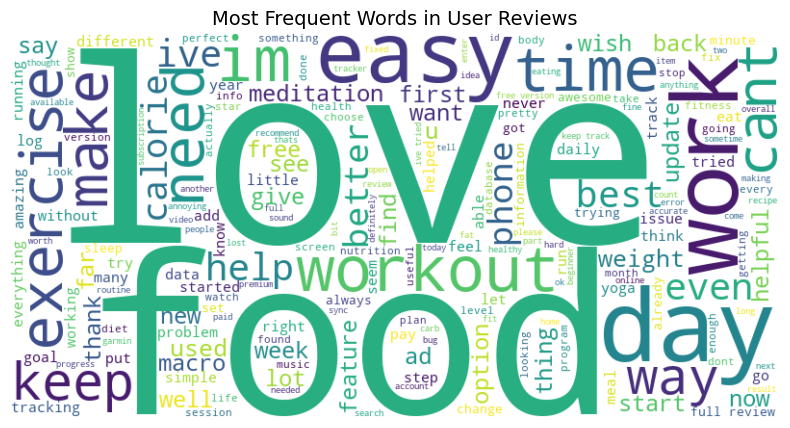

In [19]:
from wordcloud import WordCloud,STOPWORDS 
import matplotlib.pyplot as plt

text = " ".join(df["Translated_Review"].astype(str))
text = text.lower()
text = re.sub(r"[^a-z\s]", "", text)

custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "app", "apps", "use", "using", "good", "great", "nice",
    "one", "also", "really", "much", "get", "still"
])

wordcloud = WordCloud(width=800, height=400, background_color='white',stopwords=custom_stopwords).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Most Frequent Words in User Reviews", fontsize=14)
plt.show()

In [20]:
# Sentiment cross tab

sentiment_crosstab = pd.crosstab(
    df['Rating'],
    df['Sentiment'],
    margins=True,
    margins_name='Total'
)

sentiment_crosstab

Sentiment,Negative,Neutral,Positive,Total
Rating,,,,
3.7,0,1,3,4
3.9,21,9,51,81
4.0,15,12,151,178
4.1,20,14,44,78
4.2,11,10,42,63
4.3,7,20,91,118
4.4,16,18,128,162
4.5,33,32,223,288
4.6,38,31,275,344


#### Insights
##### Do all 5-star reviews have positive sentiment?
- Yes , all 4.9 star reviews have a positive sentiment.
##### Do any 1-star reviews have positive sentiment? (misclassified)
- There were no 1 star reviews.
##### What % of 3-star reviews are neutral?
- 11.8 % of the 3 star reviews are neutral